In [88]:
# Импорт необходимых библиотек
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

In [89]:
# =========================
# 1. Загрузка данных
# =========================
data = pd.read_csv('fish_train.csv')

# =========================
# 2. Разделение на train/test
# =========================
X = data.drop('Weight', axis=1)
y = data['Weight']

# Стратификация по колонке Species
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=41, stratify=X['Species']
)

In [90]:
# =========================
# 1. Выборочное среднее колонки Width на тренировочной выборке
# =========================
width_mean = X_train['Width'].mean()
print("1. Среднее Width (train):", width_mean)

1. Среднее Width (train): 4.546578947368421


In [91]:
# =========================
# 2. Базовая модель линейной регрессии без категориальных признаков
# =========================
X_train_num = X_train.drop('Species', axis=1)
X_test_num = X_test.drop('Species', axis=1)

lr = LinearRegression()
lr.fit(X_train_num, y_train)
y_pred = lr.predict(X_test_num)

r2_basic = r2_score(y_test, y_pred)
print("2. r2_score базовой модели:", r2_basic)

2. r2_score базовой модели: 0.8856498149502386


In [92]:
# =========================
# 3. Тройка наиболее коррелированных признаков
# =========================
corr_matrix = data.drop('Species', axis=1).corr().abs()
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

most_corr = list(upper.transpose()['Weight'].sort_values(ascending=False).index[:3])
print("3. Тройка наиболее коррелированных признаков:", ', '.join(most_corr))

3. Тройка наиболее коррелированных признаков: Length3, Length2, Length1


In [95]:
# =========================
# 4. PCA для тройки коррелированных признаков
# =========================
pca_features = X_train_num[most_corr]
pca = PCA(n_components=1)
pca_train = pca.fit_transform(pca_features)
pca_test = pca.transform(X_test_num[most_corr])

explained_var_ratio = pca.explained_variance_ratio_[0]
print("4. Доля объясненной дисперсии первой главной компоненты:", explained_var_ratio)

4. Доля объясненной дисперсии первой главной компоненты: 0.9960212211614189


In [96]:
# =========================
# 5. Замена тройки признаков на PCA
# =========================
X_train_pca = X_train_num.drop(columns=most_corr)
X_train_pca['Lengths'] = pca_train
X_test_pca = X_test_num.drop(columns=most_corr)
X_test_pca['Lengths'] = pca_test

lr.fit(X_train_pca, y_train)
y_pred_pca = lr.predict(X_test_pca)
r2_pca = r2_score(y_test, y_pred_pca)
print("5. r2_score после PCA:", r2_pca)

5. r2_score после PCA: 0.872450663398541


In [97]:
# =========================
# 6. Возведение признаков в куб
# =========================
for col in ['Width', 'Height', 'Lengths']:
    X_train_pca[col] = X_train_pca[col] ** 3
    X_test_pca[col] = X_test_pca[col] ** 3

width_mean_cubed = X_train_pca['Width'].mean()
print("6. Среднее Width после возведения в куб:", width_mean_cubed)

6. Среднее Width после возведения в куб: 126.76474709406482


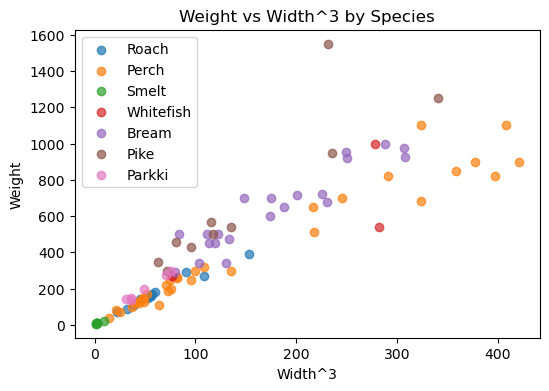

In [98]:
# =========================
# 7. Scatter-график Weight vs Width с цветом по Species
# =========================
plt.figure(figsize=(6,4))

# Получаем список уникальных видов рыб
species_list = X_train['Species'].unique()
colors = plt.cm.tab10.colors  # 10 различных цветов

for i, sp in enumerate(species_list):
    idx = X_train['Species'] == sp
    plt.scatter(X_train_pca.loc[idx, 'Width'], y_train[idx], 
                color=colors[i % 10], label=sp, alpha=0.7)

plt.xlabel('Width^3')
plt.ylabel('Weight')
plt.title('Weight vs Width^3 by Species')
plt.legend()
plt.show()

In [99]:
# =========================
# 8. Линейная регрессия после кубов
# =========================
lr.fit(X_train_pca, y_train)
y_pred_cubed = lr.predict(X_test_pca)
r2_cubed = r2_score(y_test, y_pred_cubed)
print("8. r2_score после кубов:", r2_cubed)

8. r2_score после кубов: 0.9024357840234988


In [100]:
# =========================
# 9. Добавление категориальных признаков (One-Hot Encoding)
# =========================
X_train_full = X_train_pca.join(pd.get_dummies(X_train['Species']))
X_test_full = X_test_pca.join(pd.get_dummies(X_test['Species']))

lr.fit(X_train_full, y_train)
y_pred_full = lr.predict(X_test_full)
r2_full = r2_score(y_test, y_pred_full)
print("9. r2_score с One-Hot Encoding:", r2_full)

9. r2_score с One-Hot Encoding: 0.9199406392417584


In [101]:
# =========================
# 10. One-Hot с drop_first=True
# =========================
X_train_full2 = X_train_pca.join(pd.get_dummies(X_train['Species'], drop_first=True))
X_test_full2 = X_test_pca.join(pd.get_dummies(X_test['Species'], drop_first=True))

lr.fit(X_train_full2, y_train)
y_pred_full2 = lr.predict(X_test_full2)
r2_full2 = r2_score(y_test, y_pred_full2)
print("10. r2_score с One-Hot drop_first:", r2_full2)

10. r2_score с One-Hot drop_first: 0.9199406392417528
